Starting replay_plot.ipynb execution...
Computing GT EE pos via FK...

Average Joint Position Error per Timestep (all joints):
Joint 0: Mean Abs Error = 0.039462
Joint 1: Mean Abs Error = 0.057099
Joint 2: Mean Abs Error = 0.049275
Joint 3: Mean Abs Error = 0.041839
Joint 4: Mean Abs Error = 0.010703
Joint 5: Mean Abs Error = 0.022751
Absolute Average: 0.036855


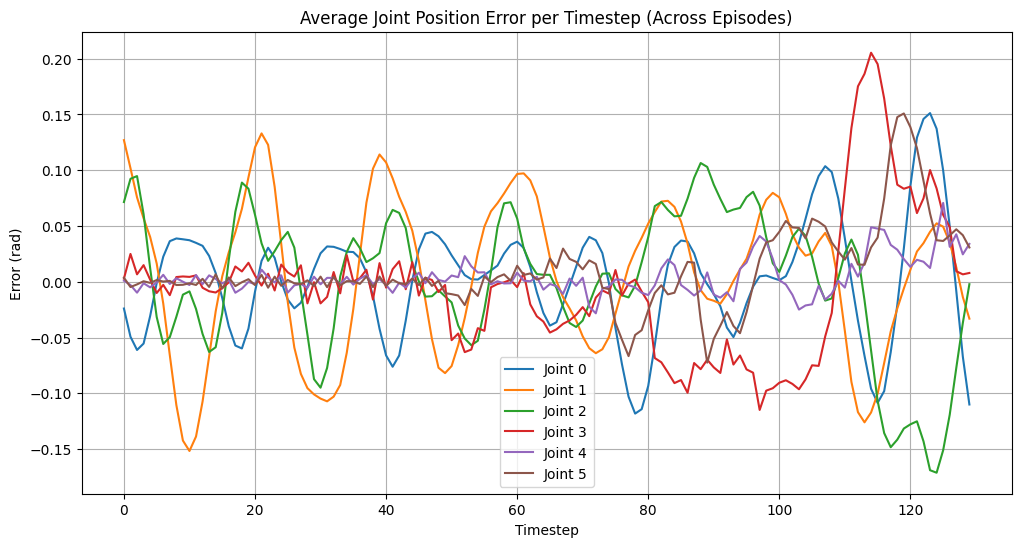


Average EE Position Error per Timestep (X, Y, Z):
  X: Mean Abs Error = 0.021673
  Y: Mean Abs Error = 0.028305
  Z: Mean Abs Error = 0.038864
Absolute Average: 0.029614


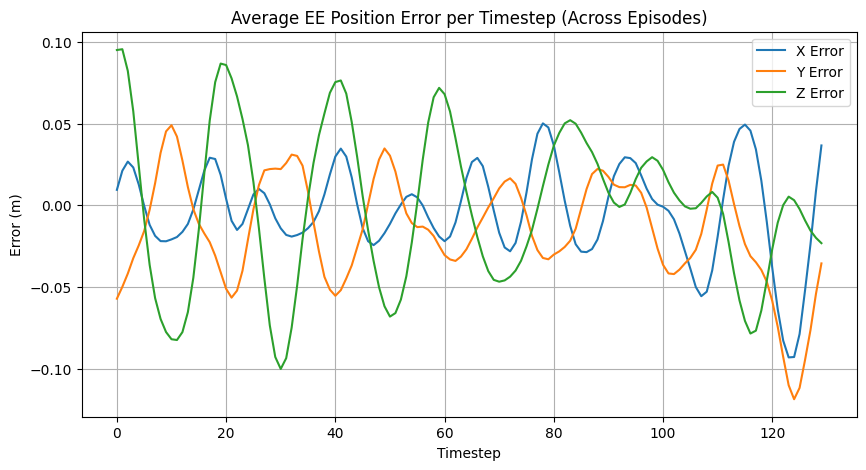

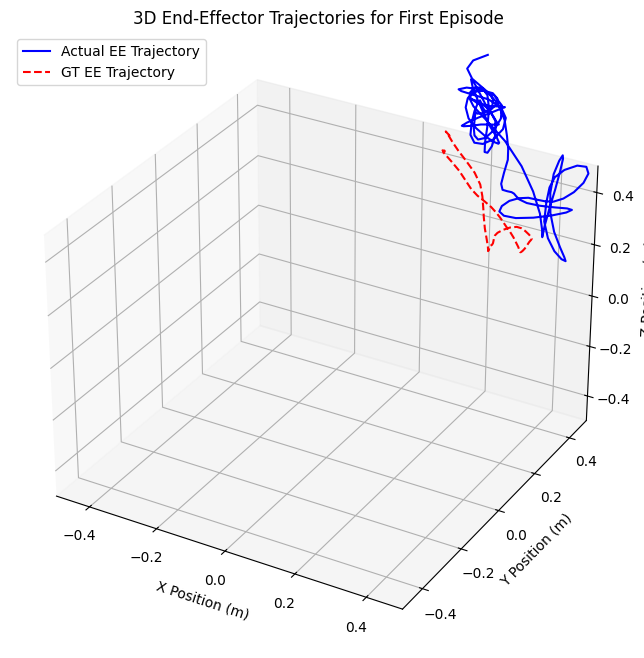

In [4]:
print("Starting replay_plot.ipynb execution...")

import os
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import ikpy.chain
try:
    ur5_chain = ikpy.chain.Chain.from_urdf_file("realm/robots/ur5/ur5_robot.urdf", active_links_mask=[False, True, True, True, True, True, True, False])
except Exception as e:
    print(f"Failed to load URDF for FK: {e}")
    ur5_chain = None

def get_fk_ee_pos(qpos):
    if ur5_chain is None:
        return np.zeros(3)
    # qpos has shape (N, 6) or (6,)
    if len(qpos.shape) == 1:
        links = [0] + list(qpos[:6]) + [0]
        return ur5_chain.forward_kinematics(links)[:3, 3]
    else:
        ee_pos = []
        for q in qpos:
            links = [0] + list(q[:6]) + [0]
            ee_pos.append(ur5_chain.forward_kinematics(links)[:3, 3])
        return np.array(ee_pos)


# 1. Define the log path
# IMPORTANT: Change this to your actual log directory path

#log_path = "logs/replay_trajectory/20260306_064554" # DROID aligned
#log_path = "logs/replay_trajectory/20260307_151211" # 100 runs ***

#log_path = "logs/replay_trajectory/20260306_153603" # DROID default PD
#log_path = "logs/replay_trajectory/20260307_165458" # 100 runs ***

#log_path = "logs/replay_trajectory/20260307_142953" DROID polaris PD
#log_path = "logs/replay_trajectory/20260307_151156" # 100 runs ***


#log_path = "logs/replay_trajectory//20260306_163848/" # UR5

#log_path = "logs/replay_trajectory/20260306_122509/" # UR5 default
#log_path = "logs/replay_trajectory/20260306_161836/"

#log_path = "logs/replay_trajectory/20260306_062729/" # UR5 naive PD

# UR5 aligned PD 
#log_path = "logs/replay_trajectory/20260306_191926/"
#log_path = "logs/replay_trajectory/20260307_135546/"
#log_path = "logs/replay_trajectory/20260307_141203/"
#log_path = "logs/replay_trajectory/20260307_143203/"
#log_path = "logs/replay_trajectory/20260307_173026/"


# 2. Parse all pkl files
pkl_files = glob.glob(os.path.join(log_path, "*.pkl"))

if not pkl_files:
    print(f"No .pkl files found in {log_path}. Please ensure the log_path is correct and contains .pkl files.")
else:
    all_qpos_errs = []
    all_ee_pos_errs = []
    
    first_ee_pos = None
    first_ee_pos_gt = None # To store ground truth EE position for the first episode
    
    for i, pkl_file in enumerate(pkl_files):
        try:
            with open(pkl_file, 'rb') as f:
                res_dict = pickle.load(f)


            if 'qpos_err' in res_dict and res_dict['qpos_err'] is not None:
                all_qpos_errs.append(res_dict['qpos_err'])
            
            if 'ee_pos_err' in res_dict and res_dict['ee_pos_err'] is not None:
                res_dict['ee_pos_err'][..., -1] -= 0.73 + 0.00819
                all_ee_pos_errs.append(res_dict['ee_pos_err'])
            elif 'qpos_joints' in res_dict and res_dict['qpos_joints'] is not None and 'trajectory_gt_qpos' in res_dict and res_dict['trajectory_gt_qpos'] is not None:
                actual_ee = get_fk_ee_pos(res_dict['qpos_joints'])
                gt_ee = get_fk_ee_pos(res_dict['trajectory_gt_qpos'])
                min_len = min(actual_ee.shape[0], gt_ee.shape[0])
                ee_err = actual_ee[:min_len] - gt_ee[:min_len]
                all_ee_pos_errs.append(ee_err)
            
            if i == 0:
                if 'ee_pos' in res_dict and res_dict['ee_pos'] is not None:
                    res_dict['ee_pos'][..., -1] -= 0.73 + 0.00819
                    first_ee_pos = res_dict['ee_pos']
                elif 'qpos_joints' in res_dict and res_dict['qpos_joints'] is not None:
                    print("Computing actual EE pos via FK...")
                    first_ee_pos = get_fk_ee_pos(res_dict['qpos_joints'])
                if 'trajectory_gt_ee' in res_dict and res_dict['trajectory_gt_ee'] is not None:
                    first_ee_pos_gt = res_dict['trajectory_gt_ee']
                elif 'trajectory_gt_qpos' in res_dict and res_dict['trajectory_gt_qpos'] is not None:
                    print("Computing GT EE pos via FK...")
                    first_ee_pos_gt = get_fk_ee_pos(res_dict['trajectory_gt_qpos'])
        except Exception as e:
            print(f"Error processing {pkl_file}: {e}")
            continue

    
    # 5. Average error per timestep for all joints individually
    if all_qpos_errs:
        # Assuming all qpos_errs have the same number of timesteps and dof
        # Find the minimum number of timesteps across all collected qpos_errs
        min_steps_qpos = min(err.shape[0] for err in all_qpos_errs)
        # Truncate all qpos_errs to this minimum length
        padded_qpos_errs = [err[:min_steps_qpos, :] for err in all_qpos_errs]
        avg_qpos_err_per_timestep = np.mean(np.array(padded_qpos_errs), axis=0)
        
        print("\nAverage Joint Position Error per Timestep (all joints):")
        print("\n".join(f"Joint {i}: Mean Abs Error = {v:.6f}" for i, v in enumerate(np.mean(np.abs(avg_qpos_err_per_timestep), axis=0))))
        print(f"Absolute Average: {np.mean(np.abs(avg_qpos_err_per_timestep)):.6f}")
        
        # Plotting average joint errors
        plt.figure(figsize=(12, 6))
        plt.plot(avg_qpos_err_per_timestep)
        plt.title("Average Joint Position Error per Timestep (Across Episodes)")
        plt.xlabel("Timestep")
        plt.ylabel("Error (rad)")
        plt.grid(True)
        plt.legend([f"Joint {j}" for j in range(avg_qpos_err_per_timestep.shape[1])])
        plt.show()
    else:
        print("\nNo joint position error data (qpos_err) to analyze or plot.")

    # 6. Average XYZ error in EE pos per time step averaged over the episodes
    if all_ee_pos_errs:
        # Find the minimum number of timesteps across all collected ee_pos_errs
        min_steps_ee = min(err.shape[0] for err in all_ee_pos_errs)
        # Truncate all ee_pos_errs to this minimum length
        padded_ee_pos_errs = [err[:min_steps_ee, :] for err in all_ee_pos_errs]
        avg_ee_pos_err_per_timestep = np.mean(np.array(padded_ee_pos_errs), axis=0)
        
        print("\nAverage EE Position Error per Timestep (X, Y, Z):")
        print(f"  X: Mean Abs Error = {np.mean(np.abs(avg_ee_pos_err_per_timestep[:, 0])):.6f}")
        print(f"  Y: Mean Abs Error = {np.mean(np.abs(avg_ee_pos_err_per_timestep[:, 1])):.6f}")
        print(f"  Z: Mean Abs Error = {np.mean(np.abs(avg_ee_pos_err_per_timestep[:, 2])):.6f}")
        print(f"Absolute Average: {np.mean(np.abs(avg_ee_pos_err_per_timestep)):.6f}")
        
        # Plotting average EE errors
        plt.figure(figsize=(10, 5))
        plt.plot(avg_ee_pos_err_per_timestep)
        plt.title("Average EE Position Error per Timestep (Across Episodes)")
        plt.xlabel("Timestep")
        plt.ylabel("Error (m)")
        plt.legend(['X Error', 'Y Error', 'Z Error'])
        plt.grid(True)
        plt.show()
    else:
        print("\nNo end-effector position error data (ee_pos_err) to analyze or plot. This might be because 'traj_ee_gt' was not available for the replayed trajectories.")

    # 7. Plot EE pos as 3D points for the first pkl file, including GT if available
    if first_ee_pos is not None:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot(first_ee_pos[:, 0], first_ee_pos[:, 1], first_ee_pos[:, 2], label='Actual EE Trajectory', color='blue')
        
        if first_ee_pos_gt is not None:
            # Truncate GT to match actual trajectory length if different
            if first_ee_pos_gt.shape[0] > first_ee_pos.shape[0]:
                first_ee_pos_gt = first_ee_pos_gt[:first_ee_pos.shape[0], :]
            elif first_ee_pos.shape[0] > first_ee_pos_gt.shape[0]:
                first_ee_pos = first_ee_pos[:first_ee_pos_gt.shape[0], :]
            ax.plot(first_ee_pos_gt[:, 0], first_ee_pos_gt[:, 1], first_ee_pos_gt[:, 2], label='GT EE Trajectory', color='red', linestyle='--')
        else:
            print("\nNote: Ground Truth EE Trajectory (ee_pos_gt) not found for the first episode in the .pkl file. This might be because 'traj_ee_gt' was not available or not saved by the replay script (e.g., for UR5 trajectories).")
            
        ax.set_xlabel('X Position (m)')
        ax.set_ylabel('Y Position (m)')
        ax.set_zlabel('Z Position (m)')
        ax.set_xlim(-0.5, 0.5)
        ax.set_ylim(-0.5, 0.5)
        ax.set_zlim(-0.5, 0.5)
        ax.set_title(f"3D End-Effector Trajectories for First Episode")
        ax.legend()
        plt.grid(True)
        plt.show()
    else:
        print("\nNo actual EE position data to plot for the first episode.")
